# WCC: recovering an AGN / TDE flare with differential photometry (TDAMM)

Tidal disruption events and AGN flares are found as a nucleus brightening by a few tenths of a magnitude
over days. This notebook injects a flaring, **host-free point source with a stellar (G2V) SED** into a real
Gaia DR3 field as a stand-in for an AGN nucleus, renders a sequence of WCC frames with `wcc_sim`, and asks
**how well `wcc_phot` recovers the injected light curve against an ensemble of field stars, and how the
precision degrades with target magnitude.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).


**At a glance** · Advanced · Package: `wcc_sim + wcc_phot`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** image arrays plus intermediates can exceed 1 GB; run alone and restart the kernel afterward.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** recovery against a simplified simulator is not a calibrated observing-performance forecast.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from wcc_sim import simulate_field
from wcc_sim.catalog import query_gaia
from wcc_phot import run_photometry

out = Path("gallery_outputs")
out.mkdir(exist_ok=True)  # persistent attendee-facing report

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
TARGET_G = 18.0       # Gaia G magnitude of host-free proxy
FRAME_TIME = 60.0     # seconds
N_REF = 10            # number of comparison stars
FLARE_SCALE = 1.0     # scales injected magnitude change


## 1. A Gaia field with an injected variable point source

Gaia DR3 stars within 60" of (RA, Dec) = (300.0, +30.0), plus one synthetic G = 18 row at the field
centre. Its Gaia colours are NaN, so `wcc_sim` renders it with its default G2V template: a **host-free
stellar-SED proxy** for an AGN, with no galaxy light and no AGN power-law colour. Passing the table as
`catalog=` bypasses the live Gaia query, so the magnitude can be changed frame by frame.


In [3]:
RA, DEC = 300.0, 30.0
cat = query_gaia(RA, DEC, radius_arcsec=60, mag_limit=21.0, cache_dir="gaia_cache")
agn = {k: np.nan for k in cat.colnames}
agn.update(source_id=1, ra=RA, dec=DEC, phot_g_mean_mag=TARGET_G)
cat.add_row(agn)
print(f"{len(cat) - 1} Gaia sources + 1 injected AGN proxy (source_id=1)")

308 Gaia sources + 1 injected AGN proxy (source_id=1)


## 2. Eight 60 s frames of a 0.35 mag flare on a 2048 px (35") subarray

A larger 4096 px square subarray holds three float64 images (~400 MB) and eight of them ~3 GB; the 2048 px subarray
keeps the sequence under 1 GB. Reference-star availability is checked after the cut.


In [4]:
N = 2048                                                              # subarray side [px]
dmag = FLARE_SCALE * np.array([0.0, 0.0, -0.10, -0.25, -0.35, -0.30, -0.20, -0.10])   # injected light curve
frames = []
for k, dm in enumerate(dmag):
    cat["phot_g_mean_mag"][-1] = TARGET_G + dm
    frames.append(simulate_field(RA, DEC, sensorfilter="zwo:r", focus=0, exptime=FRAME_TIME, seed=k,
                                 shape=(N, N), catalog=cat))
c = frames[0].catalog
ok = np.asarray(c["in_image"], bool) & ~np.asarray(c["saturated"], bool)
near = ok & (np.abs(c["phot_g_mean_mag"] - TARGET_G) < 1.0) & (c["source_id"] != 1)
mem = sum(a.nbytes for f in frames for a in (f.image_adu, f.image_e, f.image_clean)) / 1e9
print(f"{ok.sum()} unsaturated stars in the {N} px frame ({near.sum()} within 1 mag of G = {TARGET_G:g}), "
      f"{int(frames[0].saturation_mask.sum())} saturated pixels; {mem:.2f} GB of image arrays")

target_rows = np.asarray(c["source_id"] == 1)
assert target_rows.sum() == 1 and np.all(ok[target_rows]), "Injected target must be unique, in frame and unsaturated"
assert (ok & ~target_rows).sum() >= N_REF >= 2, "Need at least N_REF unsaturated comparison stars (N_REF >= 2)"


30 unsaturated stars in the 2048 px frame (5 within 1 mag of G = 18), 29 saturated pixels; 0.40 GB of image arrays


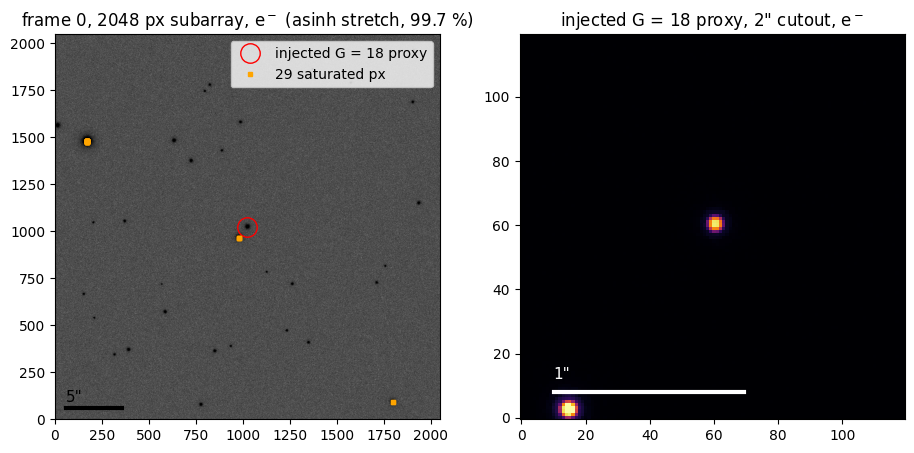

In [5]:
PLATE = frames[0].params["plate_scale_mas"]                          # mas / px
x0, y0 = [float(c[c["source_id"] == 1][k][0]) for k in ("x", "y")]
img = frames[0].image_e
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img, origin="lower", cmap="gray_r", norm=simple_norm(img, "asinh", percent=99.7))
axes[0].plot(x0, y0, "o", ms=14, mfc="none", mec="r", label=f"injected G = {TARGET_G:g} proxy")
ys, xs = np.nonzero(frames[0].saturation_mask)
axes[0].plot(xs, ys, "s", ms=3, color="orange", label=f"{xs.size} saturated px")
bar = 5000 / PLATE                                                    # 5" scale bar in px
axes[0].plot([60, 60 + bar], [60, 60], "k-", lw=3); axes[0].text(60, 90, '5"', fontsize=11)
axes[0].legend(loc="upper right"); axes[0].set_title(f"frame 0, {N} px subarray, e$^-$ (asinh stretch, 99.7 %)")
cut = np.s_[int(y0) - 60:int(y0) + 60, int(x0) - 60:int(x0) + 60]
axes[1].imshow(img[cut], origin="lower", cmap="inferno", norm=simple_norm(img[cut], "asinh", percent=99.9))
axes[1].plot([10, 10 + 1000 / PLATE], [8, 8], "w-", lw=3); axes[1].text(10, 12, '1"', color="w", fontsize=11)
axes[1].set_title(f"injected G = {TARGET_G:g} proxy, 2\" cutout, e$^-$")
plt.show()


## 3. Differential aperture photometry against 10 reference stars

In [6]:
res = run_photometry(frames, target=1, method="aperture", n_ref=N_REF, times=np.arange(len(dmag)) * 0.5,
                     report=f"{out}/wcc02_report.pdf")
print(f"aperture radius {res.params['r_ap']} px, annulus {res.params['r_in']}-{res.params['r_out']} px; "
      f"{res.params['n_ref']} reference stars, G = {res.stars['gmag'][1:].min():.2f}-{res.stars['gmag'][1:].max():.2f}")
stars = res.stars["star", "role", "source_id", "gmag"]
stars["sep_arcsec"] = 3600 * np.hypot((res.stars["ra"] - RA) * np.cos(np.radians(DEC)), res.stars["dec"] - DEC)
stars["gmag"].format = stars["sep_arcsec"].format = "%.2f"
stars


aperture radius 9.0 px, annulus 13.5-22.5 px; 10 reference stars, G = 18.39-19.26


star,role,source_id,gmag,sep_arcsec
int64,str6,int64,float64,float64
0,target,1,18.00,0.00
1,ref,2030222695717090944,18.39,10.16
2,ref,2030222691407002880,18.72,11.74
3,ref,2030222760126484224,18.72,18.58
4,ref,2030222695743480064,18.91,7.79
5,ref,2030222691410957952,19.02,15.34
6,ref,2030222691410963072,19.11,10.62
7,ref,2030222691407703936,19.14,16.49
8,ref,2030222695743623680,19.23,11.53


The [native diagnostic PDF](gallery_outputs/wcc02_report.pdf) and [PNG](gallery_outputs/wcc02_report.png) are saved in `gallery_outputs/` and displayed below. Its target RMS and binning curve include the injected flare, so they are **not residual-noise estimates**. Inspect flags in the report. The science comparison below excludes every epoch with any flagged target/reference measurement; the precision sweep excludes flagged frames too. Epochs are illustrative, not a cadence simulation.


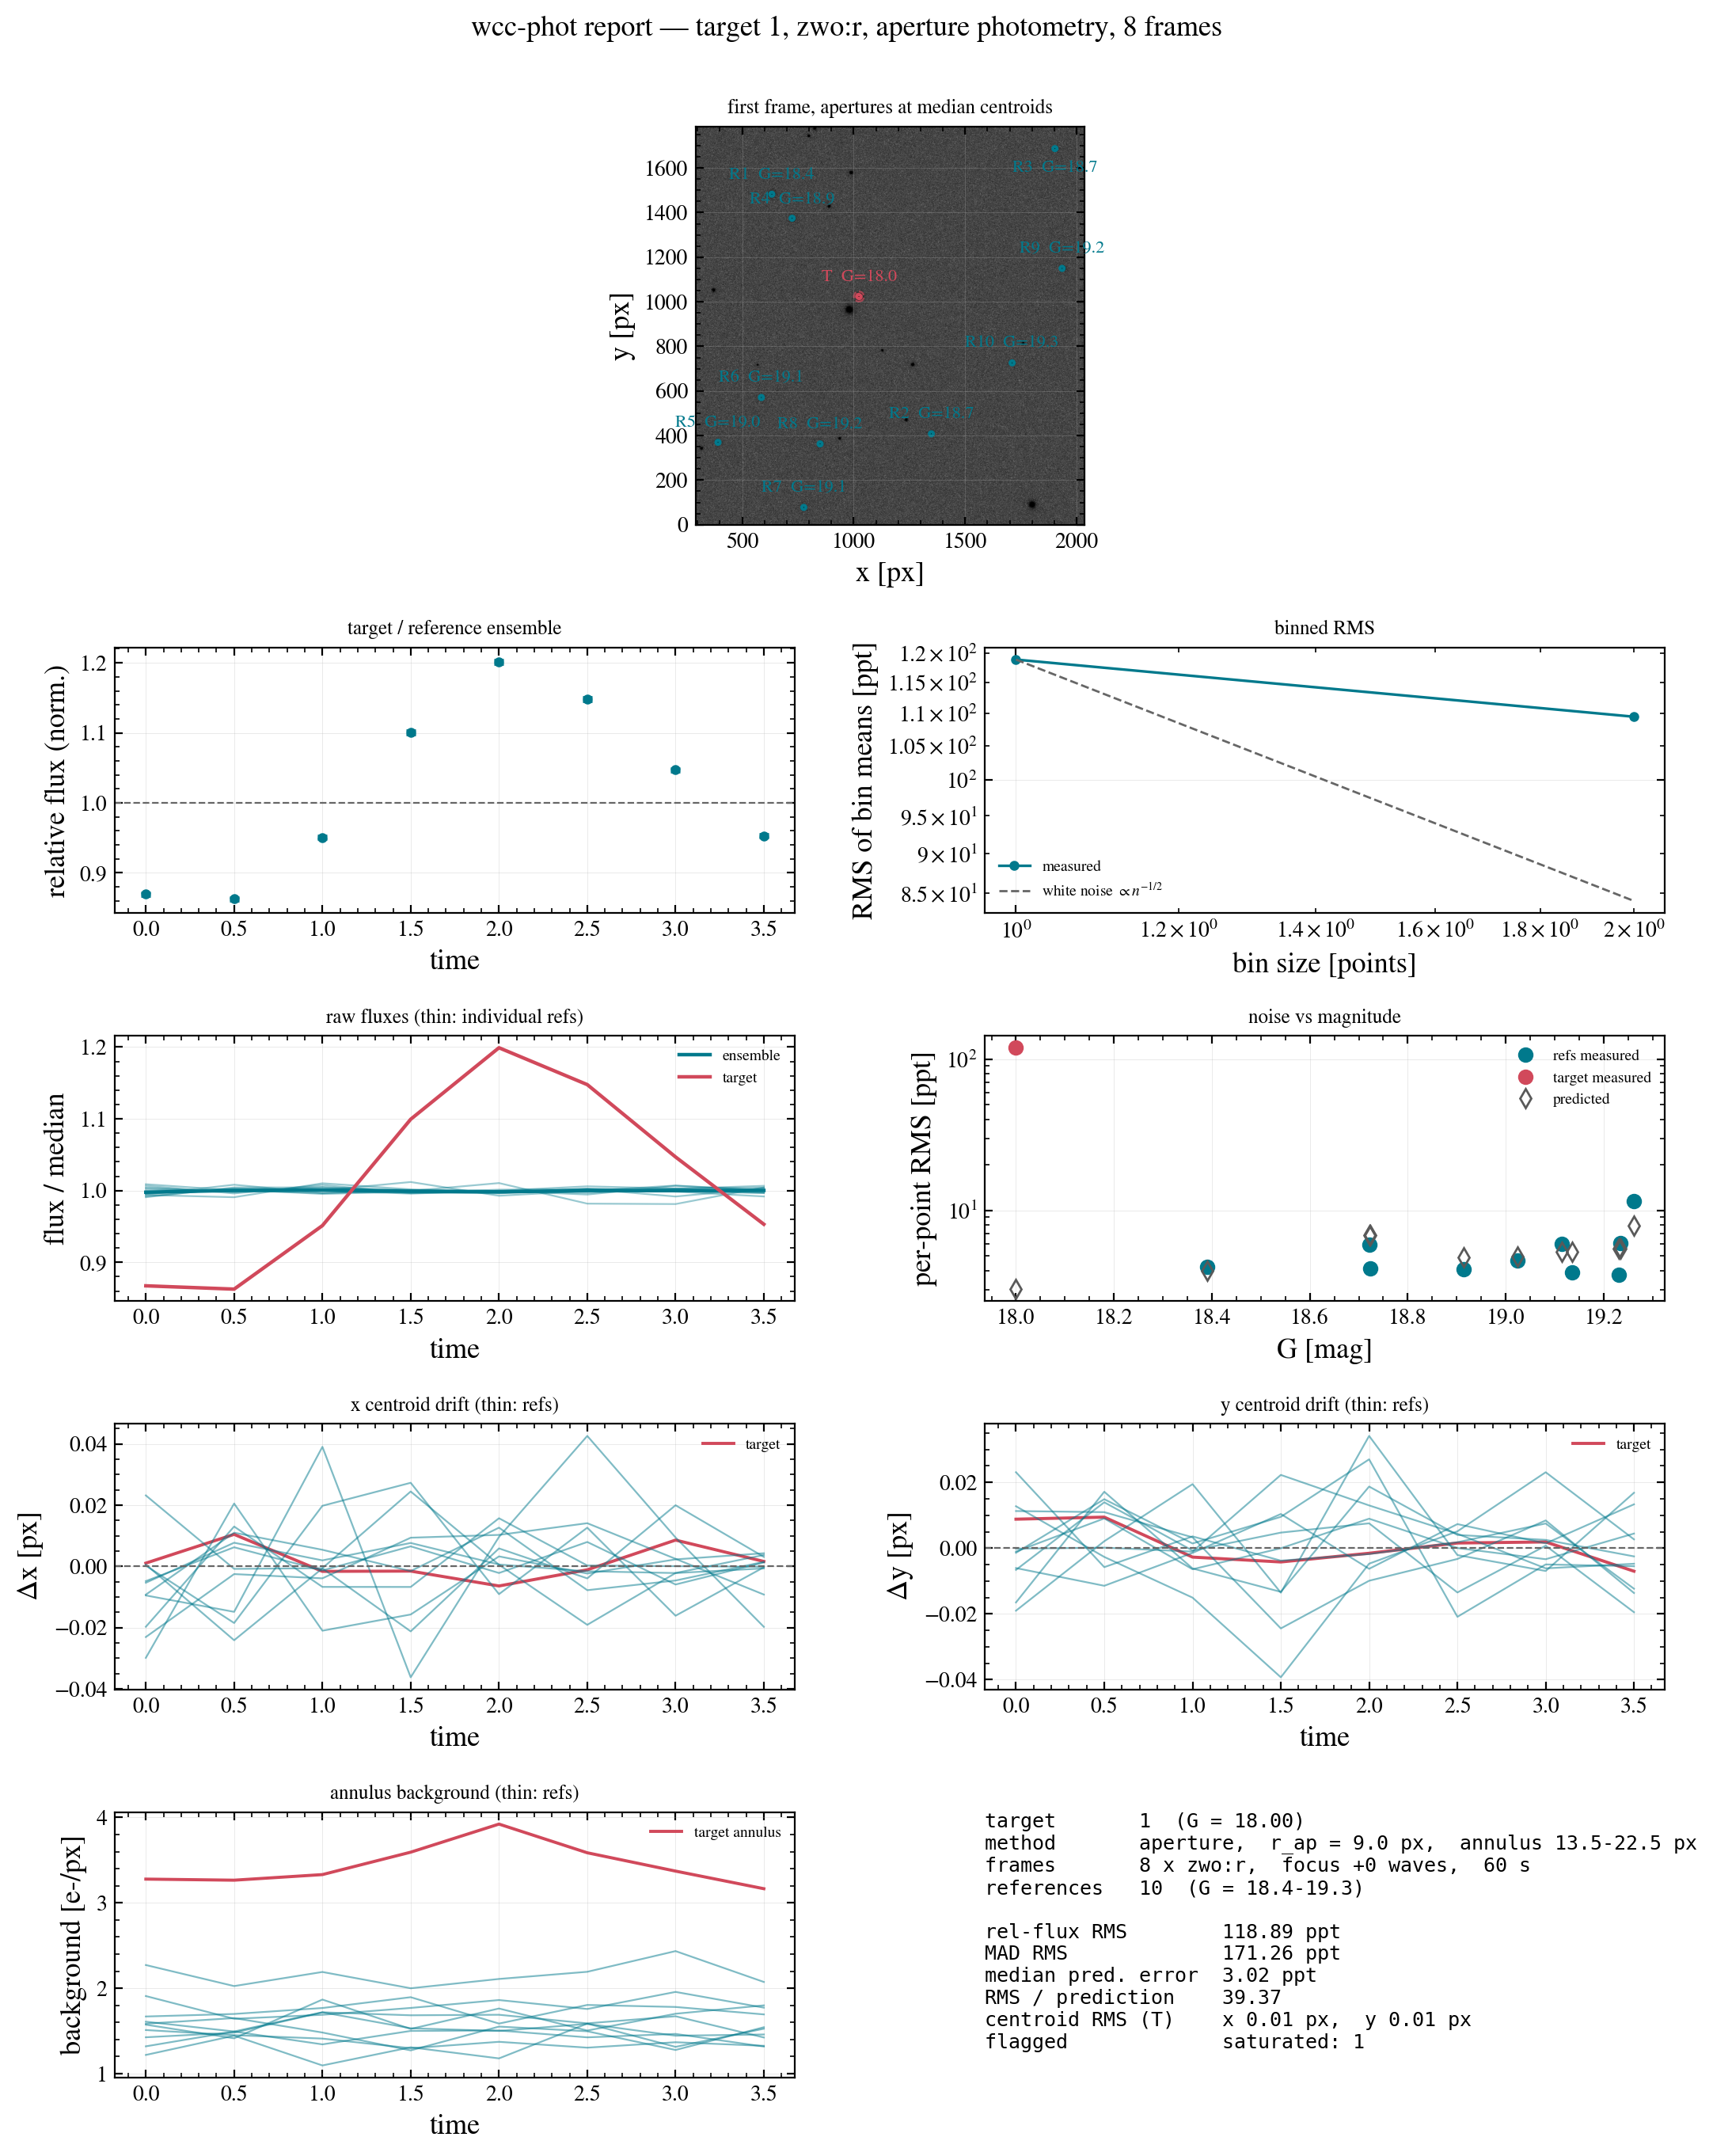

Native diagnostics: /Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/schmidt_observatories_symposium_2026/Lazuli/WCC/gallery_outputs/wcc02_report.pdf
Excluded flagged recovery epochs (zero based): [4]


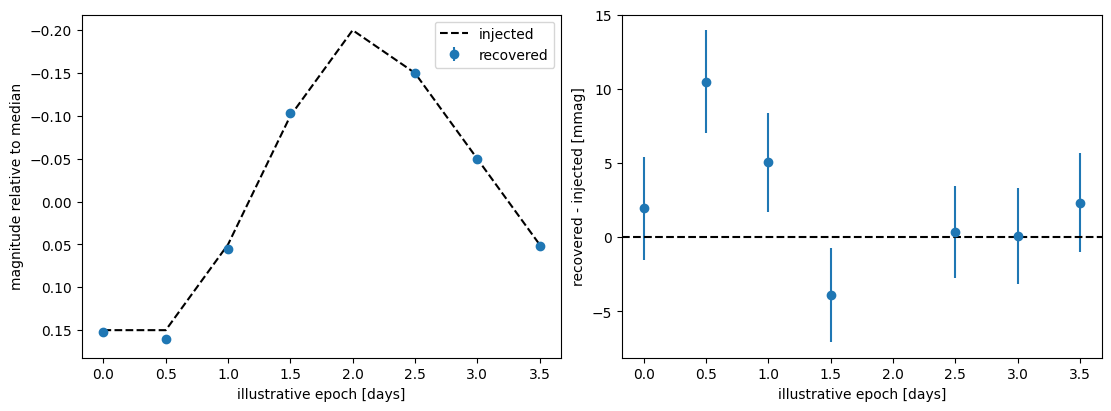

Residual RMS 4.2 mmag; median propagated error 3.3 mmag


In [7]:
display(Image(filename=str(out / "wcc02_report.png")))
print("Native diagnostics:", (out / "wcc02_report.pdf").resolve())
lc = res.lightcurve
assert np.all(np.isfinite(lc["rel_flux_norm"])) and np.all(lc["rel_flux_norm"] > 0), "Invalid recovered relative flux"
flagged_frames = np.unique(res.measurements["frame"][res.measurements["flags"] != 0])
valid = ~np.isin(np.arange(len(lc)), flagged_frames)
print("Excluded flagged recovery epochs (zero based):", flagged_frames.tolist())
assert valid.any(), "No unflagged epochs remain for recovery"
rec = np.where(valid, -2.5 * np.log10(lc["rel_flux_norm"]), np.nan)
rec_err = np.where(valid, 2.5 / np.log(10) * lc["rel_flux_norm_err"] / lc["rel_flux_norm"], np.nan)
inj = dmag - np.median(dmag)
resid = np.asarray(rec - inj)
fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].plot(lc["time"], inj, "k--", label="injected")
ax[0].errorbar(lc["time"], rec, yerr=rec_err, fmt="o", label="recovered")
ax[0].invert_yaxis(); ax[0].set(xlabel="illustrative epoch [days]", ylabel="magnitude relative to median"); ax[0].legend()
ax[1].errorbar(lc["time"], 1e3*resid, yerr=1e3*rec_err, fmt="o")
ax[1].axhline(0, color="k", ls="--"); ax[1].set(xlabel="illustrative epoch [days]", ylabel="recovered - injected [mmag]")
plt.show()
print(f"Residual RMS {1e3*np.nanstd(resid):.1f} mmag; median propagated error {1e3*np.nanmedian(rec_err):.1f} mmag")


## 4. Photometric precision versus nucleus magnitude

Three constant-brightness frames per magnitude; the quoted precision is the median per-frame error bar.

G=16: 3 of 3 frames flagged; excluded from precision
G = 16: nan mmag per 60 s frame


G=17: 3 of 3 frames flagged; excluded from precision
G = 17: nan mmag per 60 s frame


G = 18: 3.4 mmag per 60 s frame


G = 19: 5.2 mmag per 60 s frame


G = 20: 8.5 mmag per 60 s frame


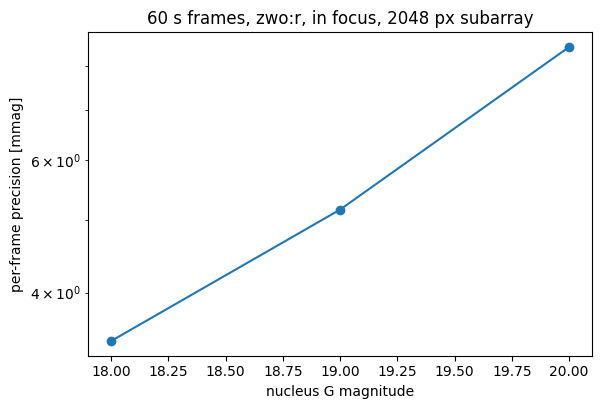

In [8]:
mags = [16, 17, 18, 19, 20]
prec = []
for m in mags:
    cat["phot_g_mean_mag"][-1] = m
    fr = [simulate_field(RA, DEC, sensorfilter="zwo:r", focus=0, exptime=FRAME_TIME, seed=100 + k,
                         shape=(N, N), catalog=cat) for k in range(3)]
    r = run_photometry(fr, target=1, n_ref=N_REF)
    flagged = np.unique(r.measurements["frame"][r.measurements["flags"] != 0])
    good = ~np.isin(np.arange(len(r.lightcurve)), flagged)
    uncertainty = r.lightcurve["rel_flux_norm_err"] / r.lightcurve["rel_flux_norm"]
    prec.append(1e3 * 2.5 / np.log(10) * np.median(uncertainty[good]) if good.any() else np.nan)
    if not good.all():
        print(f"G={m}: {int((~good).sum())} of {len(good)} frames flagged; excluded from precision")
    print(f"G = {m}: {prec[-1]:.1f} mmag per {FRAME_TIME:g} s frame")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(mags, prec, "o-")
ax.set(xlabel="nucleus G magnitude", ylabel="per-frame precision [mmag]", title=f"{FRAME_TIME:g} s frames, zwo:r, in focus, {N} px subarray")
plt.show()

## Reference-run takeaway (default scene)

The host-free G2V proxy recovers a large injected flare, but the default peak epoch is flagged as saturated and excluded from the science residuals. G=16 and G=17 are also saturated in the 60 s precision scan and cannot support a bright-end precision claim. Read the current residual RMS and valid precision points above, alongside the native diagnostic flags.

The report's target RMS includes astrophysical variability; the custom injection residual plot is the relevant recovery diagnostic. Only three constant-brightness frames per magnitude are used for propagated uncertainty, not stable empirical RMS. The reference ensemble, host light, realistic AGN SED and longer-term systematics need separate investigation. A 4096-square image would be a larger subarray, with a substantial memory cost, not the full detector.


## Try this

1. Set FLARE_SCALE to 0.5. Compare the recovered amplitude and residual error.
2. Set N_REF to 5. Compare propagated uncertainty and the native reference diagnostics.

**Extension:** Add galaxy light before interpreting the point-source proxy as an AGN nucleus.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
